<a href="https://colab.research.google.com/github/N7-cyber/uts-pengolahan-citra-digital/blob/main/Uts_Pengolahan_Citra__Digital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = Image.open(filename).convert('L')
img = np.array(img)

print("Ukuran gambar:", img.shape)
print("Rata-rata piksel original:", np.mean(img))

Saving ChatGPT Image 29 Apr 2026, 16.08.47 (1).png to ChatGPT Image 29 Apr 2026, 16.08.47 (1).png
Ukuran gambar: (1491, 1055)
Rata-rata piksel original: 125.55935613682092


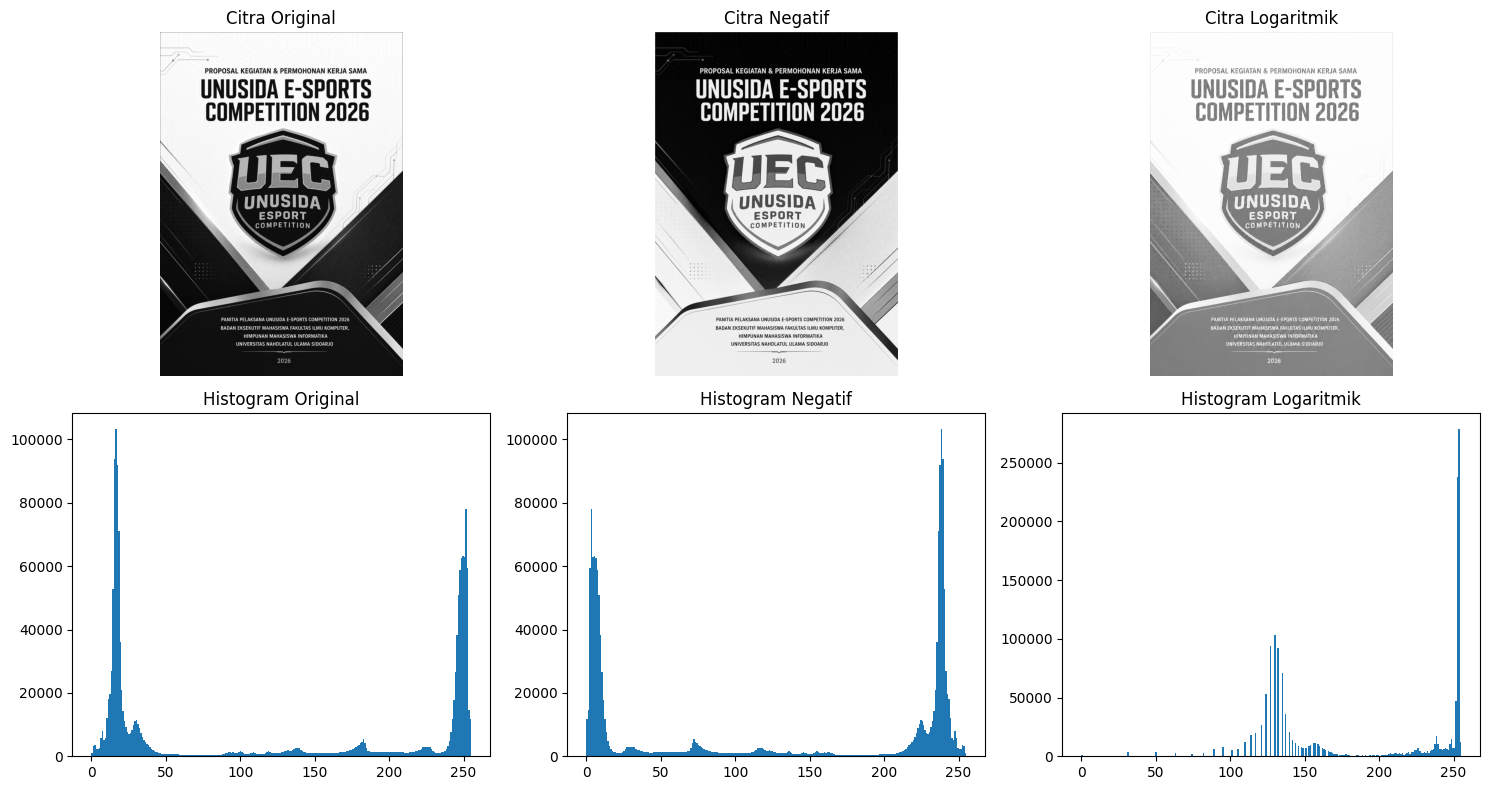

Rata-rata piksel original: 125.55935613682092
Rata-rata piksel negatif: 129.44064386317908
Rata-rata piksel logaritmik: 192.23932091760673


In [6]:
negative_img = 255 - img

img_float = img.astype(np.float32)
fmax = np.max(img_float)
c = 255 / np.log(1 + fmax)

log_img = c * np.log(1 + img_float)
log_img = np.uint8(np.clip(log_img, 0, 255))

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Citra Original')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(negative_img, cmap='gray')
plt.title('Citra Negatif')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(log_img, cmap='gray')
plt.title('Citra Logaritmik')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.hist(img.ravel(), bins=256, range=(0, 255))
plt.title('Histogram Original')

plt.subplot(2, 3, 5)
plt.hist(negative_img.ravel(), bins=256, range=(0, 255))
plt.title('Histogram Negatif')

plt.subplot(2, 3, 6)
plt.hist(log_img.ravel(), bins=256, range=(0, 255))
plt.title('Histogram Logaritmik')

plt.tight_layout()
plt.show()

print("Rata-rata piksel original:", np.mean(img))
print("Rata-rata piksel negatif:", np.mean(negative_img))
print("Rata-rata piksel logaritmik:", np.mean(log_img))

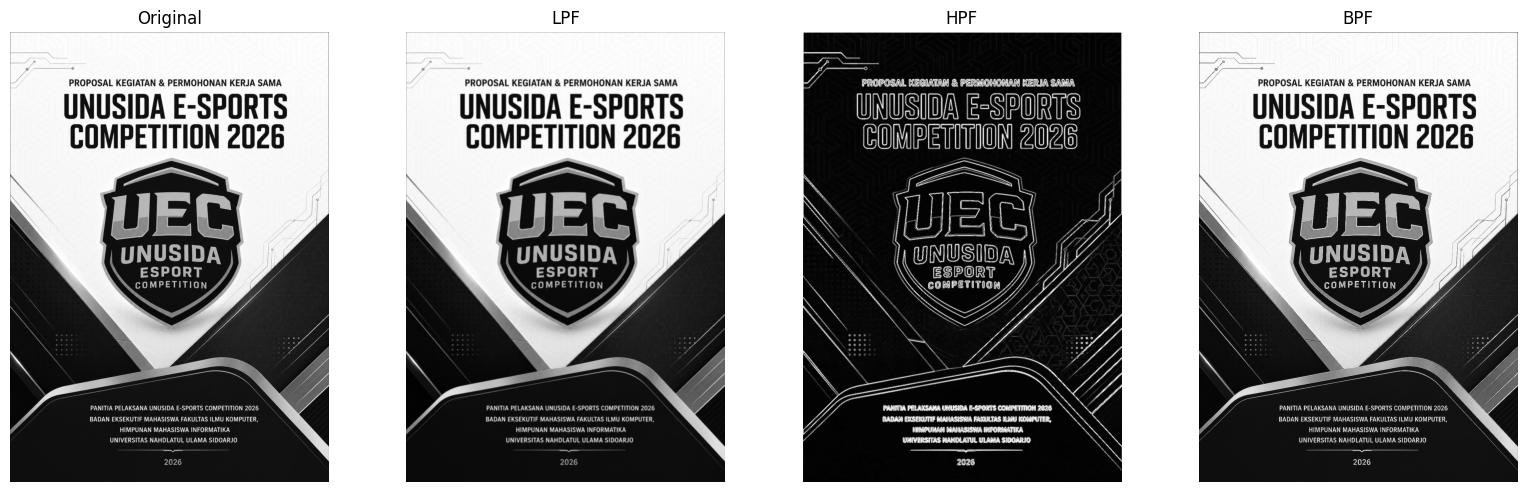

Rata-rata piksel original: 125.55935613682092
Rata-rata piksel LPF: 125.63710223425863
Rata-rata piksel HPF: 27.787452678154235
Rata-rata piksel BPF: 125.6647664819883


In [3]:
lpf_kernel = (1/9) * np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.float32)

hpf_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

bpf_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float32)

lpf_img = cv2.filter2D(img, -1, lpf_kernel)

hpf_raw = cv2.filter2D(img.astype(np.float32), cv2.CV_32F, hpf_kernel)
hpf_img = cv2.convertScaleAbs(hpf_raw)

bpf_raw = cv2.filter2D(img.astype(np.float32), cv2.CV_32F, bpf_kernel)
bpf_img = np.uint8(np.clip(bpf_raw, 0, 255))

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(lpf_img, cmap='gray')
plt.title('LPF')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(hpf_img, cmap='gray')
plt.title('HPF')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(bpf_img, cmap='gray')
plt.title('BPF')
plt.axis('off')

plt.tight_layout()
plt.show()

mean_original = np.mean(img)
mean_lpf = np.mean(lpf_img)
mean_hpf = np.mean(hpf_img)
mean_bpf = np.mean(bpf_img)

print("Rata-rata piksel original:", mean_original)
print("Rata-rata piksel LPF:", mean_lpf)
print("Rata-rata piksel HPF:", mean_hpf)
print("Rata-rata piksel BPF:", mean_bpf)